<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CycleGAN Exercise

In this lab, we will implement the key components of **CycleGAN** and train it on a small **Monet ↔ Photo** dataset.

The challenge we want to solve is to translate images between two visual domains (a kind of style transfer), but without any paired examples.
We only have a dataset of Monet images and a dataset of unrelated Photo images.

Like in plain GAN, we train generators (Monet→Photo and Photo→Monet) by co-training discriminators and using an adversarial loss
(the discriminator should distinguish real and fake images, while the generator wants to fool the discriminator).

Question: what can happen if we only use that adversarial loss? What can we add?

In this notebook we will implement the CycleGAN loss from the original [paper](https://arxiv.org/pdf/1703.10593.pdf).

In [1]:
from collections.abc import Sequence
from pathlib import Path

import ipywidgets
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from tqdm.notebook import tqdm


device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)

cpu


## Dataset

In [2]:
%%bash
mkdir -p data
if [ ! -d "data/MONET-IMAGES" ]; then
    gdown 'https://drive.google.com/uc?id=1-3-u9l5qcUcIkdBuztqEAeZA8p_QEFcN' -O data/monet.zip
    unzip -q -d data/ data/monet.zip
fi

Downloading...
From: https://drive.google.com/uc?id=1-3-u9l5qcUcIkdBuztqEAeZA8p_QEFcN
To: /content/data/monet.zip
100%|██████████| 1.52M/1.52M [00:00<00:00, 146MB/s]


In [3]:
class ImageDataset(Dataset):
    def __init__(
        self,
        root: Path = Path("data/MONET-IMAGES"),
        transform: v2.Transform | None = None,
        aligned: bool = True,
    ) -> None:
        self.transform = transform
        self.aligned = aligned

        self.files_monet = sorted((root / "monet_jpg").glob("*.jpg"))
        self.files_photo = sorted((root / "photo_jpg").glob("*.jpg"))
        assert len(self.files_monet) == len(self.files_photo) == 50, (
            f"Expected 50+50 images, found {len(self.files_monet)}+{len(self.files_photo)} in {root}/monet_jpg and /photo_jpg"
        )

    def __getitem__(self, index: int) -> dict:
        image_monet = PIL.Image.open(self.files_monet[index]).convert("RGB")

        if not self.aligned:
            index = np.random.randint(0, len(self.files_photo) - 1)

        image_photo = PIL.Image.open(self.files_photo[index]).convert("RGB")

        if self.transform:
            image_monet = self.transform(image_monet)
            image_photo = self.transform(image_photo)

        return {"Monet": image_monet, "Photo": image_photo}

    def __len__(self) -> int:
        return len(self.files_monet)

In [4]:
def as_widget(img: PIL.Image.Image) -> ipywidgets.Image:
    return ipywidgets.Image(value=img._repr_jpeg_())


display(ipywidgets.HBox([as_widget(ImageDataset()[i]["Monet"]) for i in range(5)]))
display(ipywidgets.HBox([as_widget(ImageDataset()[i]["Photo"]) for i in range(5)]))

## Models
### (Task 1). Residual Block

It should accept one argument: `in_features`, and perform the following operations:

1. 3×3 convolution,
2. Instance norm,
3. Activation (ReLU),
4. 3×3 convolution,
5. Instance norm,
6. Residual connection

Both convolutions should preserve the number of filters and preserve the size by using reflection padding.

In [5]:
class ResidualBlock(nn.Module):
    # TODO {
    def __init__(self, in_features: int) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_features, in_features, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(),
            nn.Conv2d(in_features, in_features, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.InstanceNorm2d(in_features),
        )
    def forward(self, x):
      return self.conv(x) + x
    # }

### Generator
Now we will use this block to build the generator and discriminator networks.

For the generator, the important thing is that we downsample, then process, then upsample the spatial dimensions, in order to encourage a less literal internal representation and to have a large receptive field.

In [6]:
class GeneratorResNet(nn.Module):
    def __init__(self, image_shape: Sequence[int], num_residual_blocks: int) -> None:
        super().__init__()

        C, H, W = image_shape

        # Initial convolution block.
        out_features = 64
        layers = [
            nn.Conv2d(
                C, out_features, kernel_size=7, padding=3, padding_mode="reflect"
            ),
            nn.InstanceNorm2d(out_features),
            nn.ReLU(inplace=True),
        ]
        in_features = out_features

        # Downsampling.
        for _ in range(2):
            out_features *= 2
            layers.extend(
                [
                    nn.Conv2d(
                        in_features, out_features, kernel_size=3, stride=2, padding=1
                    ),
                    nn.InstanceNorm2d(out_features),
                    nn.ReLU(inplace=True),
                ]
            )
            in_features = out_features

        # Residual blocks.
        for _ in range(num_residual_blocks):
            layers.extend([ResidualBlock(out_features)])

        # Upsampling.
        for _ in range(2):
            out_features //= 2
            layers.extend(
                [
                    nn.Upsample(scale_factor=2, mode="nearest"),
                    nn.Conv2d(
                        in_features, out_features, kernel_size=3, stride=1, padding=1
                    ),
                    nn.ReLU(inplace=True),
                ]
            )
            in_features = out_features

        # Output Layer
        layers.extend(
            [
                nn.Conv2d(
                    out_features, C, kernel_size=7, padding=3, padding_mode="reflect"
                ),
                nn.Tanh(),
            ]
        )

        # Unpacking
        self.layers = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.layers(x)

### Discriminator

In [7]:
class Discriminator(nn.Module):
    def __init__(self, image_shape: Sequence[int], normalize: bool = True) -> None:
        super().__init__()

        C, H, W = image_shape

        def block(
            in_filters: int, out_filters: int, stride: int = 1, normalize: bool = True
        ) -> list[nn.Module]:
            layers=  list[nn.Module]()
            layers.append(
                nn.Conv2d(in_filters, out_filters, kernel_size=4, stride=stride, padding=1)
            )
            # if normalize:
            #     layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.layers = nn.Sequential(
            *block(C, 64, stride=2, normalize=False),
            *block(64, 128, stride=2, normalize=normalize),
            *block(128, 256, stride=2, normalize=normalize),
            *block(256, 512, normalize=normalize),
            nn.Conv2d(512, 1, kernel_size=4, padding=1),
        )

        # Calculate output shape of image discriminator (PatchGAN)
        self.output_shape = (1, H // 2**3 - 2, W // 2**3 - 2)


    def forward(self, img: Tensor) -> Tensor:
        output = self.layers(img)
        assert output.shape[1:] == self.output_shape, f"Expected output shape {self.output_shape}, got {output.shape[1:]}"
        return output

Question: the discriminator outputs not a single scalar, but a feature map.
* What does the following code show?
* Why, what will be the effect of using a discriminator with such an output?

In [8]:
def example():
    image_shape = (3, 256, 256)
    model = Discriminator(image_shape, normalize=False).to(device).eval()
    x = torch.randn(size=(1, *image_shape), requires_grad=True, device=device)
    output = model(x)
    _B, _1, pH, pW = output.shape
    output[0, 0, pH // 2, pW // 2].backward()
    assert x.grad is not None
    nonzero = (x.grad.abs() > 1e-9)
    print(np.round(np.sqrt(nonzero[0, 0].sum().cpu().numpy())))
    print(nonzero[0, 0, 127].to(torch.int64))

example()

70.0
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


## Training

In [9]:
image_shape = (3, 256, 256)  # (C, H, W)

# Training:
start_epoch = 0  # epoch to start training from
n_epochs = 20  # number of epochs of training
batch_size = 1  # size of the batches

# Optimizer:
lr = 1e-4  # adam : learning rate
b1 = 0.5  # adam : decay of first order momentum of gradient
b2 = 0.999  # adam : decay of first order momentum of gradient

image_transform = v2.Compose(
    [
        v2.RandomResizedCrop((image_shape[1], image_shape[2]), interpolation=v2.InterpolationMode.BICUBIC),
        v2.RandomHorizontalFlip(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
)

num_workers = 2

Now let us define few networks:
- `G_MonetToPhoto` - that is used to transfer Monet images to Photo images
- `G_PhotoToMonet` - that is used to transfer Photo images to Monet
- `D_Photo` - discriminator for `G_MonetToPhoto`
- `D_Monet` - discriminator for `G_PhotoToMonet`

In [10]:
G_MonetToPhoto = GeneratorResNet(image_shape, num_residual_blocks=6).to(device)
G_PhotoToMonet = GeneratorResNet(image_shape, num_residual_blocks=6).to(device)
D_Monet = Discriminator(image_shape).to(device)
D_Photo = Discriminator(image_shape).to(device)

Now let us implement the optimizers:

In [11]:
import itertools

optimizer_G = torch.optim.Adam(
    itertools.chain(G_MonetToPhoto.parameters(), G_PhotoToMonet.parameters()),
    lr=lr,
    betas=(b1, b2),
)
optimizer_D_Monet = torch.optim.Adam(D_Monet.parameters(), lr=lr, betas=(b1, b2))
optimizer_D_Photo = torch.optim.Adam(D_Photo.parameters(), lr=lr, betas=(b1, b2))

In [12]:
dataset = ImageDataset(transform=image_transform, aligned=False)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=num_workers)

## Visualization

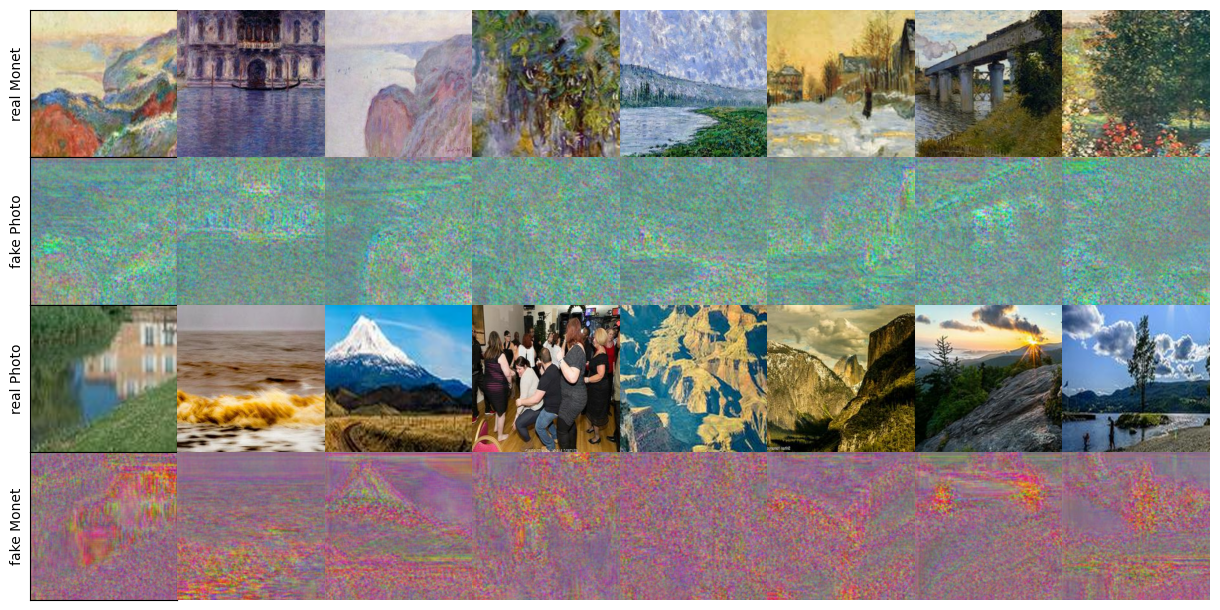

In [13]:
vis_batch = next(iter(DataLoader(dataset, batch_size=8)))

to_pil_image = v2.Compose(
    [v2.Normalize(mean=(-1, -1, -1), std=(2, 2, 2)), v2.ToPILImage()]
)


def make_and_show_samples(scale: float = 1.5) -> None:
    realMonet, realPhoto = vis_batch["Monet"].to(device), vis_batch["Photo"].to(device)

    G_MonetToPhoto.eval()
    G_PhotoToMonet.eval()
    with torch.no_grad():
        fakePhoto = G_MonetToPhoto(realMonet)
        fakeMonet = G_PhotoToMonet(realPhoto)
    rows = {"real Monet": realMonet, "fake Photo": fakePhoto, "real Photo": realPhoto, "fake Monet": fakeMonet}

    fig, axs = plt.subplots(
        len(rows), len(realMonet), figsize=(scale * len(realMonet), scale * len(rows))
    )
    fig.set_layout_engine("compressed", h_pad=0, w_pad=0, hspace=0, wspace=0)
    for row, (row_title, x) in enumerate(rows.items()):
        for col in range(len(x)):
            axs[row, col].imshow(to_pil_image(x[col]))
            axs[row, col].axis("off")
        # Title left of row.
        axs[row, 0].axis("on")
        axs[row, 0].xaxis.set_ticks([])
        axs[row, 0].yaxis.set_ticks([])
        axs[row, 0].set_ylabel(row_title, rotation=90)
    plt.show()


make_and_show_samples()

## (Task 2.) Losses and training loop

Implement the appropriate losses. Use the default `reduction="mean"` for all of them.

* GAN loss: use MSE (instead of BCE or the log-D trick).
* Cycle consistency loss: use L1.
* Identity loss: use L1; this loss is discussed later in the paper (5.2).
* For the discriminators, don't use any history buffer as suggested in the paper, just the last generated fake images (for simplicity).
  
Question:
* Why use L1 instead of MSE for comparing images?
* When giving fake images to the discriminators, should we do something?

In [14]:
CYCLE_LOSS_WEIGHT = 5.0
IDENTITY_LOSS_WEIGHT = 10.0

valid = torch.ones((batch_size, *D_Monet.output_shape), device=device)
fake = torch.zeros((batch_size, *D_Monet.output_shape), device=device)


def train_step(epoch: int, step_in_epoch: int, realMonet: Tensor, realPhoto: Tensor) -> None:
    realMonet, realPhoto = realMonet.to(device), realPhoto.to(device)

    # -----------------
    # Generators training step
    # -----------------
    G_MonetToPhoto.train()
    G_PhotoToMonet.train()
    optimizer_G.zero_grad()

    # Identity Loss
    # TODO {
    fakePhoto = G_MonetToPhoto(realMonet)
    fakeMonet = G_PhotoToMonet(realPhoto)
    sameMonet = G_PhotoToMonet(realMonet)
    samePhoto = G_MonetToPhoto(realPhoto)
    id_loss_1 = F.l1_loss(sameMonet, realMonet)
    id_loss_2 = F.l1_loss(realPhoto, samePhoto)
    id_loss = id_loss_1 + id_loss_2
    # }

    # GAN Loss
    # TODO {
    Dis_Photo = D_Photo(fakePhoto)
    Dis_Monet = D_Monet(fakeMonet)
    gan_loss = F.mse_loss(Dis_Photo, valid) + F.mse_loss(Dis_Monet, valid)
    # }

    # Cycle Loss
    # TODO {
    rec_monet = G_PhotoToMonet(fakePhoto)
    rec_photo = G_MonetToPhoto(fakeMonet)
    cyc_loss_1 = F.l1_loss(rec_monet, realMonet)
    cyc_loss_2 = F.l1_loss(rec_photo, realPhoto)
    cycle_loss = cyc_loss_1 + cyc_loss_2
    # cycle_loss =
    # }

    # Total generators loss
    loss_G = (
        gan_loss
        + (CYCLE_LOSS_WEIGHT * cycle_loss)
        + (IDENTITY_LOSS_WEIGHT * id_loss)
    )
    loss_G.backward()
    optimizer_G.step()

    # -----------------
    # Discriminator Monet training step.
    # -----------------
    criterion = nn.MSELoss(reduction="mean")  # LSGAN loss
    D_Monet.train()
    optimizer_D_Monet.zero_grad()

    # TODO {
    d2_monet = D_Monet(realMonet)
    loss1 = F.mse_loss(d2_monet, valid)
    d3_monet = D_Monet(fakeMonet.detach())
    loss2 = F.mse_loss(d3_monet, fake)
    loss_D_Monet = loss1 + loss2
    # }

    loss_D_Monet.backward()
    optimizer_D_Monet.step()

    # -----------------
    # Discriminator Photo training step.
    # -----------------
    D_Photo.train()
    optimizer_D_Photo.zero_grad()

    # TODO {
    d2_photo = D_Photo(realPhoto)
    loss1 = F.mse_loss(d2_photo, valid)
    d3_photo = D_Photo(fakePhoto.detach())
    loss2 = F.mse_loss(d3_photo, fake)
    loss_D_Real = loss1 + loss2
    # }
    # loss_D_Real =
    # }

    loss_D_Real.backward()
    optimizer_D_Photo.step()

    # -----------------
    # Show Progress
    # -----------------
    loss_D = (loss_D_Real + loss_D_Monet) / 2
    if (step_in_epoch + 1) % 25 == 0:
        make_and_show_samples()
        print(
            f"Epoch {epoch + 1}/{n_epochs} | Batch {step_in_epoch + 1}/{len(dataloader)} | "
            + f"D loss: {loss_D.item():.2f} | G loss: {loss_G.item():.2f} "
            + f"(adv: {gan_loss.item():.2f}, cycle: {cycle_loss.item():.2f}, id: {id_loss.item():.2f})"
        )

In [ ]:
for epoch in range(start_epoch, n_epochs):
    for step_in_epoch, batch in enumerate(tqdm(dataloader)):
        realMonet, realPhoto = batch["Monet"].to(device), batch["Photo"].to(device)
        train_step(epoch, step_in_epoch, realMonet=realMonet, realPhoto=realPhoto)

  0%|          | 0/50 [00:00<?, ?it/s]